In [1]:
%load_ext autoreload
%autoreload 2

In [17]:
import json
from pathlib import Path
import pandas as pd

# Premier League fixtures
pl_fixtures = []

for file in Path('data/matches/2').glob('*.json'):
    with open(file, 'r') as f:
        data = json.load(f)
        for item in data:
            pl_fixtures.append(item)
    
matches_df = pd.DataFrame(pl_fixtures)
season_norm = pd.json_normalize(matches_df['season'])
refs_norm = pd.json_normalize(matches_df['referee'])
refs_norm = refs_norm.add_prefix('referee_', axis=1)

matches_df.drop(['season', 'referee'], axis=1, inplace=True)
matches_df = pd.concat([matches_df, season_norm, refs_norm], axis=1)

In [18]:
# 2015/16 season analysis
matches_2015_16_df = matches_df[matches_df['season_name'] == '2015/2016']

avg_home_goals = matches_2015_16_df['home_score'].mean()
avg_away_goals = matches_2015_16_df['away_score'].mean()

print(f"Average scoreline: Home: {avg_home_goals:.2f} - Away: {avg_away_goals:.2f}")

Average scoreline: Home: 1.49 - Away: 1.21


Text(0, 0.5, 'Number of Matches')

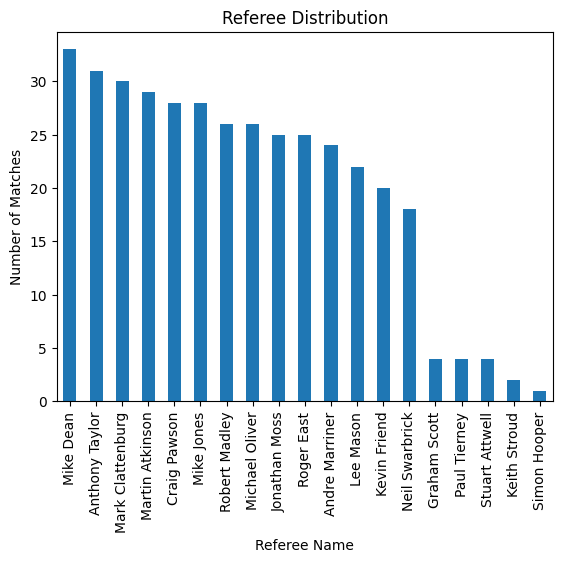

In [20]:
# Referee stats
import matplotlib.pyplot as plt
refs_df = matches_2015_16_df['referee_name'].value_counts().plot(kind='bar', stacked=True)
plt.title("Referee Distribution")
plt.xlabel("Referee Name")
plt.ylabel("Number of Matches")
